# CSI Human Activity / Fall Recognition — Notebook unifié

Ce notebook regroupe **tous les modèles** entraînés sur le dataset CSI *FallDeWideo* dans un seul notebook, avec :

1. Chargement des fichiers CSI
2. Prétraitement commun (amplitude / phase) — fait **une seule fois** pour tous les modèles
3. Split train / val / test + normalisation — **partagé** par tous les modèles
4. Baseline Machine Learning classique (Random Forest, Régression Logistique, XGBoost, SVM)
5. Modèle 1 — CNN + BiGRU
6. Modèle 2 — CNN + LSTM
7. Modèle 3 — Two-Stream Conv-Transformer (Conformer) — *THAR*
8. Récapitulatif comparatif des résultats

**Note :** l'architecture, le prétraitement et le protocole d'entraînement de chaque modèle sont **strictement identiques** à ceux des notebooks séparés d'origine. Seule la structure du notebook a changé : les étapes communes (chargement, prétraitement, split) ne sont exécutées qu'une seule fois pour économiser la mémoire/le temps sur Kaggle, et chaque modèle nettoie ses objets lourds (modèle, optimizer, DataLoaders) juste après son évaluation.


## 1. Imports & configuration globale

Configuration commune à **tous** les modèles (identique aux notebooks d'origine) : seed, device, classes, dimensions des données CSI, et hyperparamètres d'entraînement partagés (batch size, epochs, lr, weight decay, label smoothing, dropout).

In [1]:
import os, gc, json, random, math, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# --- Config dataset (identique aux 3 notebooks d'origine) ---
CLASSES = ["fall", "nfall1", "nfall2"]          # ordre = index de classe 0,1,2
LABEL2IDX = {c: i for i, c in enumerate(CLASSES)}
T_STEPS = 50          # dimension temporelle brute (paquets)
F_SUB = 30            # sous-porteuses
N_LINKS = 3            # csi0, csi1, csi2
N_ANT_KEEP = 3          # on moyenne sur la dernière dimension d'antenne (3->1), garde l'autre (3)
IN_CHANNELS = N_LINKS * N_ANT_KEEP   # = 9 canaux pour amplitude, 9 pour phase (flux séparés)

# --- Config entrainement (identique aux 3 notebooks d'origine) ---
BATCH_SIZE = 64
EPOCHS = 250                # fixe, PAS d'early stopping (comme dans les notebooks d'origine)
LR = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1
DROPOUT = 0.3

OUT_DIR = Path("/kaggle/working")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Dictionnaire qui va accumuler les résultats finaux de chaque modèle (section 9)
RESULTS = {}


Device: cuda


## 2. Chargement des fichiers CSI

Recherche automatique du dossier du dataset *FallDeWideo* et récupération de tous les fichiers `full_*.pk` (identique aux notebooks d'origine).

In [2]:
import re

def find_dataset_root():
    candidates = [
        Path("/kaggle/input/falldewideoo"),
        Path("/kaggle/input/datasets/imanemokhtari/falldewideoo"),
    ]
    candidates += [p for p in Path("/kaggle/input").glob("*") if p.is_dir()]
    for root in candidates:
        if not root.exists():
            continue
        csi_files = list(root.rglob("full_0.pk"))
        if any("/csi/" in f.as_posix() for f in csi_files):
            return root
    raise FileNotFoundError("Dataset FallDeWideo introuvable.")

DATA_ROOT = find_dataset_root()
print("DATA_ROOT:", DATA_ROOT)

def file_number(path):
    m = re.search(r"full_(\d+)\.pk$", str(path))
    return int(m.group(1)) if m else 999

all_pk = list(DATA_ROOT.rglob("full_*.pk"))
normal_csi = [p for p in all_pk if p.as_posix().endswith("/csi/csi/" + p.name)]
missing_csi = [p for p in all_pk if p.as_posix().endswith("/missing/missing/csi/" + p.name)]
csi_by_number = {file_number(p): p for p in normal_csi}
csi_by_number.update({file_number(p): p for p in missing_csi})
CSI_FILES = [csi_by_number[n] for n in sorted(csi_by_number)]
print("Fichiers CSI finaux:", len(CSI_FILES))
assert len(CSI_FILES) >= 1, "Aucun fichier CSI trouvé."


DATA_ROOT: /kaggle/input/datasets/imanemokhtari/falldewideoo
Fichiers CSI finaux: 10


## 3. Prétraitement commun (amplitude / phase)

Étape **identique** dans les 3 notebooks d'origine : extraction du label depuis le chemin `pic`, calcul de l'amplitude et de la phase (assainie / *unwrap* + retrait de tendance linéaire) pour chaque lien CSI, puis empilement en tableaux `AMP` et `PHA`.

Cette étape est coûteuse (parcourt toutes les lignes de tous les fichiers) : elle n'est donc faite **qu'une seule fois** ici, et `AMP` / `PHA` / `LABELS` sont ensuite réutilisés par la baseline ML et par les 3 modèles deep learning.

In [3]:
# Hypothese: le chemin contient tel quel un segment de dossier "fall", "nfall1"
# ou "nfall2". Si le controle ci-dessous ne retombe pas sur 15000/14300/10900,
# partage un exemple COMPLET (non tronque) de \'pic\' pour ajuster.

def extract_label(pic_path: str):
    parts = re.split(r"[\\/]+", str(pic_path).lower())
    for token in ("nfall1", "nfall2", "fall"):   # ordre important: nfall1/2 avant fall
        if token in parts:
            return token
    joined = "/".join(parts)
    for token in ("nfall1", "nfall2", "fall"):
        if token in joined:
            return token
    return None

# Diagnostic rapide sur le premier fichier
_df0 = pd.read_pickle(CSI_FILES[0])
_sample_labels = _df0["pic"].map(extract_label)
print("Exemple de labels detectes (fichier 0):")
print(_sample_labels.value_counts(dropna=False))
print("\nExemple de chemin brut (fichier 0, ligne 0):")
print(_df0["pic"].iloc[0])
del _df0, _sample_labels
gc.collect()


Exemple de labels detectes (fichier 0):
pic
nfall2    1800
nfall1    1200
fall      1020
Name: count, dtype: int64

Exemple de chemin brut (fichier 0, ligne 0):
/home/sensing/caizhijie/0702-falldewideo/data/20230612_35/falldewideo1_nfall2_lxh_lights_1000_a3_5_rc/t2_2023_06_12_21_26_54_969/2023_06_12_21_26_55_172.jpg


0

In [4]:
def sanitize_phase(phase):
    """Retire la tendance lineaire de la phase le long des sous-porteuses
    (supprime l'offset/pente aleatoire du au CFO/SFO), apres unwrap.
    phase: (T, F, A) -> retourne un tableau de meme forme."""
    phase = np.unwrap(phase, axis=1)
    Fdim = phase.shape[1]
    idx = np.arange(Fdim, dtype=np.float32)
    idx_c = idx - idx.mean()
    denom = (idx_c ** 2).sum()
    phase_mean = phase.mean(axis=1, keepdims=True)
    phase_c = phase - phase_mean
    slope = (phase_c * idx_c[None, :, None]).sum(axis=1, keepdims=True) / denom
    return phase - slope * idx_c[None, :, None] - phase_mean

def process_link(arr_complex):
    """arr_complex: (T=50, F=30, A=3, B=3) complexe.
    Moyenne sur la derniere dimension d'antenne -> (T,F,3), calcule amplitude+phase."""
    arr = arr_complex.mean(axis=-1)                 # (T,F,3)
    amp = np.abs(arr).astype(np.float32)
    phase = np.angle(arr).astype(np.float32)
    phase = sanitize_phase(phase)
    return amp, phase

def process_row(row):
    amps, phas = [], []
    for col in ("csi0", "csi1", "csi2"):
        a, p = process_link(row[col])
        amps.append(a); phas.append(p)
    amp_stack = np.concatenate(amps, axis=-1)   # (T,F,9)
    pha_stack = np.concatenate(phas, axis=-1)   # (T,F,9)
    return amp_stack.astype(np.float16), pha_stack.astype(np.float16)

amp_list, pha_list, label_list = [], [], []
n_unknown = 0

for fpath in CSI_FILES:
    print("Traitement:", fpath)
    df = pd.read_pickle(fpath)
    for i in range(len(df)):
        row = df.iloc[i]
        lab = extract_label(row["pic"])
        if lab is None:
            n_unknown += 1
            continue
        amp_f, pha_f = process_row(row)
        amp_list.append(amp_f)
        pha_list.append(pha_f)
        label_list.append(LABEL2IDX[lab])
    del df
    gc.collect()

print("Lignes sans label reconnu:", n_unknown)

AMP = np.stack(amp_list).astype(np.float16)   # (N,50,30,9)
PHA = np.stack(pha_list).astype(np.float16)   # (N,50,30,9)
LABELS = np.array(label_list, dtype=np.int64)
del amp_list, pha_list, label_list
gc.collect()

print("AMP shape:", AMP.shape, "| PHA shape:", PHA.shape)
print("Repartition des classes:")
for c, i in LABEL2IDX.items():
    print(f"  {c}: {(LABELS == i).sum()}")

EXPECTED = {"nfall1": 15000, "nfall2": 14300, "fall": 10900}
actual = {c: int((LABELS == LABEL2IDX[c]).sum()) for c in CLASSES}
if actual != EXPECTED:
    print("\n\u26a0\ufe0f ATTENTION: la repartition obtenue ne correspond PAS exactement a celle "
          "attendue (nfall1=15000, nfall2=14300, fall=10900).")
    print("Obtenu:", actual)
    print("=> Partage un exemple complet de \'pic\' pour corriger extract_label().")
else:
    print("\n\u2705 Repartition conforme a celle attendue.")


Traitement: /kaggle/input/datasets/imanemokhtari/falldewideoo/csi/csi/full_0.pk
Traitement: /kaggle/input/datasets/imanemokhtari/falldewideoo/csi/csi/full_1.pk
Traitement: /kaggle/input/datasets/imanemokhtari/falldewideoo/csi/csi/full_2.pk
Traitement: /kaggle/input/datasets/imanemokhtari/falldewideoo/csi/csi/full_3.pk
Traitement: /kaggle/input/datasets/imanemokhtari/falldewideoo/csi/csi/full_4.pk
Traitement: /kaggle/input/datasets/imanemokhtari/falldewideoo/csi/csi/full_5.pk
Traitement: /kaggle/input/datasets/imanemokhtari/falldewideoo/csi/csi/full_6.pk
Traitement: /kaggle/input/datasets/imanemokhtari/falldewideoo/csi/csi/full_7.pk
Traitement: /kaggle/input/datasets/imanemokhtari/falldewideoo/missing/missing/csi/full_8.pk
Traitement: /kaggle/input/datasets/imanemokhtari/falldewideoo/missing/missing/csi/full_9.pk
Lignes sans label reconnu: 0
AMP shape: (40200, 50, 30, 9) | PHA shape: (40200, 50, 30, 9)
Repartition des classes:
  fall: 10900
  nfall1: 15000
  nfall2: 14300

✅ Repartition

## 4. Split train / val / test + normalisation (partagés par tous les modèles)

Split stratifié 70% / 15% / 15% (identique aux notebooks d'origine, même `SEED`), statistiques de normalisation de l'amplitude calculées uniquement sur un échantillon du train (pas de fuite), et `WeightedRandomSampler` pour équilibrer les classes.

`idx_train`, `idx_val`, `idx_test`, `AMP_MEAN`, `AMP_STD` et `sampler_weights` sont ensuite réutilisés tels quels par la baseline ML et par les 3 modèles deep learning (chaque section deep learning recrée juste un `WeightedRandomSampler` à partir de `sampler_weights`, car un `Sampler` PyTorch ne se réutilise pas entre plusieurs `DataLoader`).

In [5]:
N = len(LABELS)
idx_all = np.arange(N)

idx_train, idx_temp = train_test_split(
    idx_all, test_size=0.30, stratify=LABELS[idx_all], random_state=SEED
)
idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.50, stratify=LABELS[idx_temp], random_state=SEED
)
print(f"Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}")

# Statistiques de normalisation calculees UNIQUEMENT sur le train (evite fuite)
_stat_sample = np.random.choice(idx_train, size=min(3000, len(idx_train)), replace=False)
AMP_MEAN = AMP[_stat_sample].astype(np.float32).mean()
AMP_STD = AMP[_stat_sample].astype(np.float32).std() + 1e-6
print("AMP_MEAN:", AMP_MEAN, "| AMP_STD:", AMP_STD)

# Poids par echantillon pour equilibrer les classes dans le sampler d'entrainement
train_labels = LABELS[idx_train]
class_counts = np.array([(train_labels == i).sum() for i in range(len(CLASSES))])
class_weights = 1.0 / class_counts
sample_weights = class_weights[train_labels]
sampler_weights = torch.as_tensor(sample_weights, dtype=torch.double)


Train: 28140 | Val: 6030 | Test: 6030
AMP_MEAN: 17.424976 | AMP_STD: 12.342929


## 5. Baseline Machine Learning classique (RF, Régression Logistique, XGBoost, SVM)

Avant les modèles deep learning, une baseline rapide avec des modèles classiques. Comme ces modèles ne peuvent pas prendre en entrée les séquences CSI brutes `(T=50, F=30, C=9)`, on extrait un petit vecteur de **features statistiques** par échantillon (moyenne/écart-type par canal + stats globales, pour l'amplitude et la phase) — beaucoup plus léger en mémoire que d'aplatir les tenseurs bruts.

On réutilise les mêmes `idx_train` / `idx_test` que pour les modèles deep learning (section 4). Pour le SVM (coût quadratique en nombre d'échantillons), on utilise un sous-échantillon stratifié du train afin de rester rapide sur Kaggle.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    import sys
    os.system(f"{sys.executable} -m pip install xgboost --quiet")
    from xgboost import XGBClassifier
    HAS_XGB = True


def extract_stat_features(amp_arr, pha_arr, indices):
    """Features compactes par échantillon : moyenne/écart-type par canal (9+9)
    + stats globales (mean/std/min/max) pour amplitude et phase.
    Beaucoup plus léger que d'aplatir (T,F,C) en ~13500 valeurs par flux."""
    a = amp_arr[indices].astype(np.float32)   # (n,T,F,C)
    p = pha_arr[indices].astype(np.float32)
    feats = []
    for arr in (a, p):
        n = arr.shape[0]
        flat = arr.reshape(n, -1)
        ch_mean = arr.mean(axis=(1, 2))                       # (n,C)
        ch_std = arr.std(axis=(1, 2))                         # (n,C)
        g_mean = flat.mean(axis=1, keepdims=True)
        g_std = flat.std(axis=1, keepdims=True)
        g_min = flat.min(axis=1, keepdims=True)
        g_max = flat.max(axis=1, keepdims=True)
        feats.extend([ch_mean, ch_std, g_mean, g_std, g_min, g_max])
    return np.concatenate(feats, axis=1).astype(np.float32)


X_train_ml = extract_stat_features(AMP, PHA, idx_train)
y_train_ml = LABELS[idx_train]
X_test_ml = extract_stat_features(AMP, PHA, idx_test)
y_test_ml = LABELS[idx_test]
print("X_train_ml:", X_train_ml.shape, "| X_test_ml:", X_test_ml.shape)

scaler = StandardScaler().fit(X_train_ml)
X_train_ml_s = scaler.transform(X_train_ml)
X_test_ml_s = scaler.transform(X_test_ml)

# Sous-échantillon stratifié pour le SVM (coût O(n^2)/O(n^3))
MAX_SVM = 8000
if len(idx_train) > MAX_SVM:
    _, svm_sub_idx = train_test_split(
        np.arange(len(idx_train)), test_size=MAX_SVM,
        stratify=y_train_ml, random_state=SEED,
    )
else:
    svm_sub_idx = np.arange(len(idx_train))
print("Échantillons utilisés pour le SVM:", len(svm_sub_idx))


X_train_ml: (28140, 44) | X_test_ml: (6030, 44)
Échantillons utilisés pour le SVM: 8000


In [7]:
ml_results = {}

def eval_ml_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    ml_results[name] = {"accuracy": acc, "f1_macro": f1m}
    print(f"=== {name} (test) ===")
    print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))
    print(f"Accuracy: {acc:.4f} | F1-macro: {f1m:.4f}\n")

# --- Régression Logistique ---
clf_lr = LogisticRegression(max_iter=1000, n_jobs=-1)
clf_lr.fit(X_train_ml_s, y_train_ml)
eval_ml_model("Logistic Regression", y_test_ml, clf_lr.predict(X_test_ml_s))
del clf_lr; gc.collect()

# --- Random Forest ---
clf_rf = RandomForestClassifier(n_estimators=300, max_depth=None, n_jobs=-1, random_state=SEED)
clf_rf.fit(X_train_ml, y_train_ml)
eval_ml_model("Random Forest", y_test_ml, clf_rf.predict(X_test_ml))
del clf_rf; gc.collect()

# --- XGBoost ---
clf_xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.9,
    random_state=SEED, n_jobs=-1, eval_metric="mlogloss",
)
clf_xgb.fit(X_train_ml, y_train_ml)
eval_ml_model("XGBoost", y_test_ml, clf_xgb.predict(X_test_ml))
del clf_xgb; gc.collect()

# --- SVM (RBF, sous-échantillon) ---
clf_svm = SVC(kernel="rbf", C=2.0)
clf_svm.fit(X_train_ml_s[svm_sub_idx], y_train_ml[svm_sub_idx])
eval_ml_model("SVM (RBF)", y_test_ml, clf_svm.predict(X_test_ml_s))
del clf_svm; gc.collect()

RESULTS.update({f"ML_{k}": v for k, v in ml_results.items()})


=== Logistic Regression (test) ===
              precision    recall  f1-score   support

        fall     0.5220    0.5303    0.5261      1635
      nfall1     0.5970    0.6071    0.6020      2250
      nfall2     0.5680    0.5510    0.5594      2145

    accuracy                         0.5663      6030
   macro avg     0.5623    0.5628    0.5625      6030
weighted avg     0.5664    0.5663    0.5663      6030

Accuracy: 0.5663 | F1-macro: 0.5625

=== Random Forest (test) ===
              precision    recall  f1-score   support

        fall     0.8939    0.8294    0.8604      1635
      nfall1     0.8180    0.8809    0.8483      2250
      nfall2     0.8469    0.8252    0.8359      2145

    accuracy                         0.8471      6030
   macro avg     0.8529    0.8451    0.8482      6030
weighted avg     0.8488    0.8471    0.8472      6030

Accuracy: 0.8471 | F1-macro: 0.8482

=== XGBoost (test) ===
              precision    recall  f1-score   support

        fall     0.857

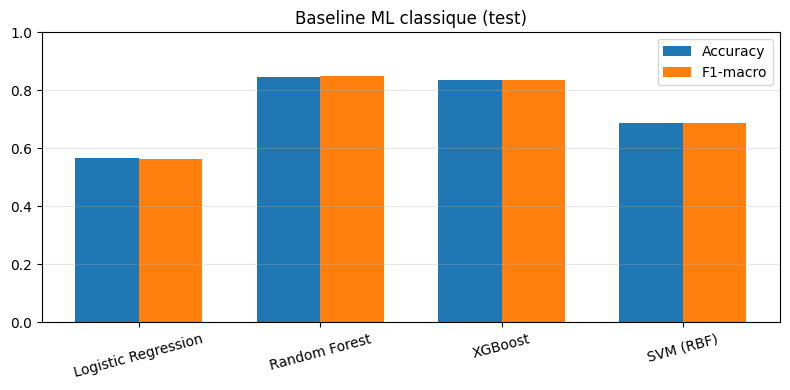

23

In [8]:
names = list(ml_results.keys())
accs = [ml_results[n]["accuracy"] for n in names]
f1s = [ml_results[n]["f1_macro"] for n in names]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(8, 4))
w = 0.35
ax.bar(x - w/2, accs, width=w, label="Accuracy")
ax.bar(x + w/2, f1s, width=w, label="F1-macro")
ax.set_xticks(x); ax.set_xticklabels(names, rotation=15)
ax.set_ylim(0, 1)
ax.set_title("Baseline ML classique (test)")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(OUT_DIR / "ml_baseline_comparison.png", dpi=150)
plt.show()

# Nettoyage mémoire de la section ML
del X_train_ml, X_test_ml, X_train_ml_s, X_test_ml_s, scaler
gc.collect()


## 6. Modèle 1 — CNN + BiGRU

Architecture, prétraitement du `Dataset`/`DataLoader` et protocole d'entraînement **strictement identiques** au notebook d'origine `cnn-bigru-csi.ipynb` : deux flux (amplitude / phase), chacun passé dans un front-end CNN 2D, embeddings concaténés puis un BiGRU avec pooling attentif.

### 6.1 Hyperparamètres du modèle

In [9]:
GRU_HIDDEN = 128
GRU_LAYERS = 2

CKPT_PATH = OUT_DIR / "best_model_cnn_bigru.pt"
HISTORY_PATH = OUT_DIR / "history_cnn_bigru.json"


### 6.2 Dataset & DataLoader (flux amplitude / phase séparés)

In [10]:
class CSIDataset(Dataset):
    def __init__(self, amp_arr, pha_arr, labels, indices, augment=False):
        self.amp = amp_arr
        self.pha = pha_arr
        self.labels = labels
        self.indices = indices
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        amp = self.amp[idx].astype(np.float32)
        pha = self.pha[idx].astype(np.float32)

        amp = (amp - AMP_MEAN) / AMP_STD
        pha = pha / np.pi

        if self.augment:
            amp = amp + np.random.normal(0, 0.02, amp.shape).astype(np.float32)
            if np.random.rand() < 0.3:
                t0 = np.random.randint(0, max(1, amp.shape[0] - 5))
                amp[t0:t0 + 5] = 0; pha[t0:t0 + 5] = 0
            if np.random.rand() < 0.3:
                f0 = np.random.randint(0, max(1, amp.shape[1] - 4))
                amp[:, f0:f0 + 4] = 0; pha[:, f0:f0 + 4] = 0

        label = self.labels[idx]
        return (
            torch.from_numpy(amp),
            torch.from_numpy(pha),
            torch.tensor(label, dtype=torch.long),
        )

train_ds = CSIDataset(AMP, PHA, LABELS, idx_train, augment=True)
val_ds = CSIDataset(AMP, PHA, LABELS, idx_val, augment=False)
test_ds = CSIDataset(AMP, PHA, LABELS, idx_test, augment=False)

sampler = WeightedRandomSampler(weights=sampler_weights, num_samples=len(idx_train), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                           num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)


### 6.3 Architecture : CNN + BiGRU (deux flux amplitude/phase)

In [11]:
class ConvFrontEnd(nn.Module):
    """CNN 2D léger (temps x fréquence) qui produit une séquence d'embeddings par
    pas de temps — sert d'entrée au GRU pour la modélisation temporelle."""
    def __init__(self, in_channels=IN_CHANNELS, base=24):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, base, kernel_size=3, padding=1),
            nn.BatchNorm2d(base), nn.ReLU(),
            nn.MaxPool2d(kernel_size=(1, 2)),          # F: 30 -> 15
            nn.Dropout2d(0.2),
            nn.Conv2d(base, base * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(base * 2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=(1, 2)),          # F: 15 -> 7
            nn.Dropout2d(0.2),
        )

    def forward(self, x):
        # x: (B,T,F,C) -> (B,C,T,F)
        x = x.permute(0, 3, 1, 2)
        out = self.net(x)                              # (B, base*2, T, F')
        out = out.permute(0, 2, 1, 3)                    # (B,T,base*2,F')
        b, t, ch, fp = out.shape
        return out.reshape(b, t, ch * fp)                 # (B,T,feat_dim)


class CNN_BiGRU(nn.Module):
    def __init__(self, in_channels=IN_CHANNELS, hidden=GRU_HIDDEN,
                 num_layers=GRU_LAYERS, num_classes=len(CLASSES), dropout=DROPOUT):
        super().__init__()
        self.amp_conv = ConvFrontEnd(in_channels)
        self.pha_conv = ConvFrontEnd(in_channels)
        with torch.no_grad():
            dummy = torch.zeros(1, T_STEPS, F_SUB, in_channels)
            feat_dim = self.amp_conv(dummy).shape[-1]

        self.input_proj = nn.Linear(feat_dim * 2, hidden)
        self.gru = nn.GRU(
            input_size=hidden, hidden_size=hidden, num_layers=num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        # pooling par attention simple sur la sortie du GRU
        self.attn = nn.Linear(hidden * 2, 1)
        self.drop = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, amp, pha):
        a = self.amp_conv(amp)
        p = self.pha_conv(pha)
        x = torch.cat([a, p], dim=-1)          # (B,T,2*feat_dim)
        x = self.input_proj(x)                  # (B,T,hidden)

        out, _ = self.gru(x)                    # (B,T,2*hidden)
        attn_scores = self.attn(out).squeeze(-1)   # (B,T)
        attn_weights = torch.softmax(attn_scores, dim=1).unsqueeze(-1)  # (B,T,1)
        pooled = (out * attn_weights).sum(dim=1)    # (B,2*hidden) - pooling attentif

        pooled = self.drop(pooled)
        return self.classifier(pooled)


model = CNN_BiGRU().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Nombre de paramètres: {n_params:,}")


Nombre de paramètres: 639,332


### 6.4 Entraînement

In [12]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    torch.set_grad_enabled(train)
    for amp, pha, y in loader:
        amp, pha, y = amp.to(DEVICE), pha.to(DEVICE), y.to(DEVICE)
        if train:
            optimizer.zero_grad()
        out = model(amp, pha)
        loss = criterion(out, y)
        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
        total_loss += loss.item() * y.size(0)
        preds = out.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
        all_preds.append(preds.detach().cpu().numpy())
        all_labels.append(y.detach().cpu().numpy())
    torch.set_grad_enabled(True)
    avg_loss = total_loss / total
    acc = correct / total
    f1 = f1_score(np.concatenate(all_labels), np.concatenate(all_preds), average="macro")
    return avg_loss, acc, f1


In [13]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [],
           "train_f1": [], "val_f1": []}
best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc, tr_f1 = run_epoch(train_loader, train=True)
    val_loss, val_acc, val_f1 = run_epoch(val_loader, train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)
    history["train_f1"].append(tr_f1); history["val_f1"].append(val_f1)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CKPT_PATH)
        flag = " (meilleur -> sauvegardé)"
    else:
        flag = ""

    dt = time.time() - t0
    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train_loss={tr_loss:.4f} acc={tr_acc:.4f} f1={tr_f1:.4f} | "
          f"val_loss={val_loss:.4f} acc={val_acc:.4f} f1={val_f1:.4f} | {dt:.1f}s{flag}")

with open(HISTORY_PATH, "w") as f:
    json.dump(history, f)


Epoch 01/250 | train_loss=0.9507 acc=0.5543 f1=0.5463 | val_loss=0.8465 acc=0.6499 f1=0.6404 | 16.5s (meilleur -> sauvegardé)
Epoch 02/250 | train_loss=0.8645 acc=0.6344 f1=0.6296 | val_loss=0.8123 acc=0.6806 f1=0.6807 | 13.6s (meilleur -> sauvegardé)
Epoch 03/250 | train_loss=0.8263 acc=0.6621 f1=0.6596 | val_loss=0.7438 acc=0.7262 f1=0.7250 | 13.7s (meilleur -> sauvegardé)
Epoch 04/250 | train_loss=0.7939 acc=0.6861 f1=0.6845 | val_loss=0.7123 acc=0.7441 f1=0.7449 | 13.6s (meilleur -> sauvegardé)
Epoch 05/250 | train_loss=0.7672 acc=0.7044 f1=0.7030 | val_loss=0.6918 acc=0.7617 f1=0.7638 | 13.7s (meilleur -> sauvegardé)
Epoch 06/250 | train_loss=0.7556 acc=0.7167 f1=0.7159 | val_loss=0.6798 acc=0.7594 f1=0.7609 | 15.0s
Epoch 07/250 | train_loss=0.7352 acc=0.7321 f1=0.7316 | val_loss=0.6647 acc=0.7726 f1=0.7752 | 13.8s (meilleur -> sauvegardé)
Epoch 08/250 | train_loss=0.7151 acc=0.7418 f1=0.7413 | val_loss=0.6543 acc=0.7786 f1=0.7801 | 14.0s (meilleur -> sauvegardé)
Epoch 09/250 | tr

### 6.5 Courbes d'entraînement

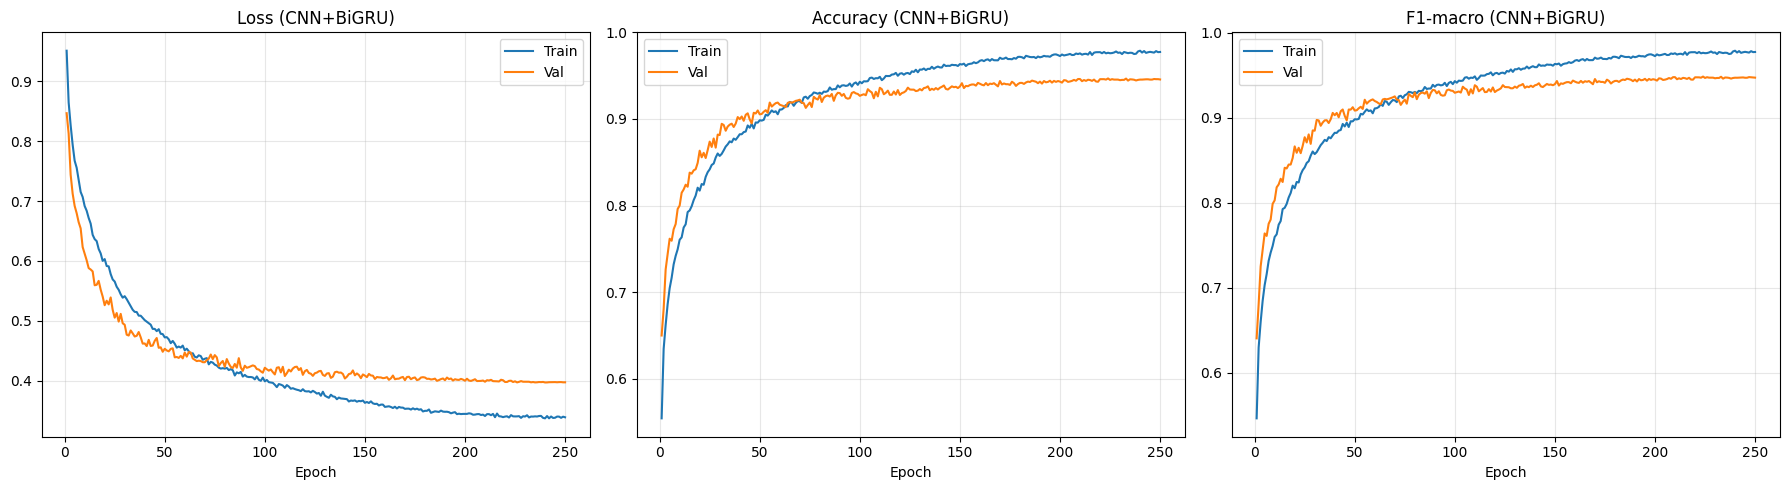

In [14]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["val_loss"], label="Val")
axes[0].set_title("Loss (CNN+BiGRU)"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="Train")
axes[1].plot(epochs_range, history["val_acc"], label="Val")
axes[1].set_title("Accuracy (CNN+BiGRU)"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_range, history["train_f1"], label="Train")
axes[2].plot(epochs_range, history["val_f1"], label="Val")
axes[2].set_title("F1-macro (CNN+BiGRU)"); axes[2].set_xlabel("Epoch"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "training_curves_cnn_bigru.png", dpi=150)
plt.show()


### 6.6 Évaluation finale sur le test set

=== Rapport de classification CNN+BiGRU (test) ===
              precision    recall  f1-score   support

        fall     0.9679    0.9596    0.9638      1635
      nfall1     0.9413    0.9329    0.9371      2250
      nfall2     0.9243    0.9389    0.9315      2145

    accuracy                         0.9423      6030
   macro avg     0.9445    0.9438    0.9441      6030
weighted avg     0.9424    0.9423    0.9423      6030



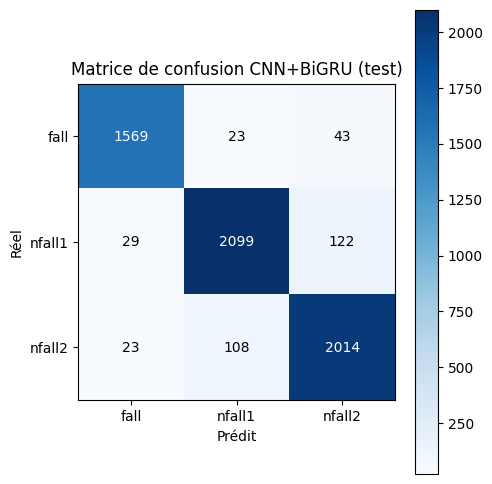


Meilleure val_acc: 0.9468


In [15]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for amp, pha, y in test_loader:
        amp, pha = amp.to(DEVICE), pha.to(DEVICE)
        out = model(amp, pha)
        preds = out.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(y.numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

print("=== Rapport de classification CNN+BiGRU (test) ===")
print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=4))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES)
ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")
ax.set_title("Matrice de confusion CNN+BiGRU (test)")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im)
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrix_cnn_bigru.png", dpi=150)
plt.show()

print(f"\nMeilleure val_acc: {best_val_acc:.4f}")

RESULTS["CNN_BiGRU"] = {
    "best_val_acc": best_val_acc,
    "test_accuracy": float((all_preds == all_labels).mean()),
    "test_f1_macro": float(f1_score(all_labels, all_preds, average="macro")),
}


### 6.7 Nettoyage mémoire

On supprime les objets lourds propres à ce modèle (modèle, optimizer, scheduler, DataLoaders, historique détaillé) avant de passer au modèle suivant, pour rester dans les limites mémoire d'un notebook Kaggle. `AMP`, `PHA`, `LABELS`, `idx_train/val/test` sont conservés car réutilisés par les modèles suivants.

In [16]:
del model, optimizer, scheduler, train_loader, val_loader, test_loader
del train_ds, val_ds, test_ds, sampler, history, all_preds, all_labels, cm
gc.collect()
torch.cuda.empty_cache()
print("Mémoire du modèle CNN+BiGRU libérée.")


Mémoire du modèle CNN+BiGRU libérée.


## 7. Modèle 2 — CNN + LSTM

Architecture, prétraitement du `Dataset`/`DataLoader` et protocole d'entraînement **strictement identiques** au notebook d'origine `cnn-lstm.ipynb` : ici amplitude et phase sont concaténées en **un seul flux à 18 canaux** (contrairement au modèle précédent à deux flux), passé dans un CNN 2D puis un LSTM unidirectionnel qui résume la séquence via son dernier état caché.

### 7.1 Hyperparamètres du modèle

In [17]:
FEAT_CHANNELS = N_LINKS * N_ANT_KEEP     # = 9
IN_CHANNELS_LSTM = FEAT_CHANNELS * 2        # = 18 (amplitude + phase concaténées en un seul flux)

LSTM_HIDDEN = 128
LSTM_LAYERS = 2

CKPT_PATH = OUT_DIR / "best_model_cnn_lstm.pt"
HISTORY_PATH = OUT_DIR / "history_cnn_lstm.json"


### 7.2 Dataset & DataLoader (flux unique amplitude+phase concaténé)

In [18]:
class CSIDataset(Dataset):
    def __init__(self, amp_arr, pha_arr, labels, indices, augment=False):
        self.amp = amp_arr
        self.pha = pha_arr
        self.labels = labels
        self.indices = indices
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        amp = self.amp[idx].astype(np.float32)
        pha = self.pha[idx].astype(np.float32)

        amp = (amp - AMP_MEAN) / AMP_STD
        pha = pha / np.pi

        if self.augment:
            amp = amp + np.random.normal(0, 0.02, amp.shape).astype(np.float32)
            if np.random.rand() < 0.3:
                t0 = np.random.randint(0, max(1, amp.shape[0] - 5))
                amp[t0:t0 + 5] = 0; pha[t0:t0 + 5] = 0
            if np.random.rand() < 0.3:
                f0 = np.random.randint(0, max(1, amp.shape[1] - 4))
                amp[:, f0:f0 + 4] = 0; pha[:, f0:f0 + 4] = 0

        x = np.concatenate([amp, pha], axis=-1)   # (T,F,18) - flux unique
        label = self.labels[idx]
        return torch.from_numpy(x), torch.tensor(label, dtype=torch.long)

train_ds = CSIDataset(AMP, PHA, LABELS, idx_train, augment=True)
val_ds = CSIDataset(AMP, PHA, LABELS, idx_val, augment=False)
test_ds = CSIDataset(AMP, PHA, LABELS, idx_test, augment=False)

sampler = WeightedRandomSampler(weights=sampler_weights, num_samples=len(idx_train), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                           num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)


### 7.3 Architecture : CNN encoder + LSTM (flux unique)

In [19]:
class CNNEncoder(nn.Module):
    """Extracteur CNN 2D (temps x fréquence) sur le flux unique amplitude+phase,
    produit une séquence d'embeddings par pas de temps pour le LSTM."""
    def __init__(self, in_channels=IN_CHANNELS_LSTM, base=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, base, kernel_size=3, padding=1),
            nn.BatchNorm2d(base), nn.ReLU(),
            nn.MaxPool2d(kernel_size=(1, 2)),          # F: 30 -> 15
            nn.Dropout2d(0.2),
            nn.Conv2d(base, base * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(base * 2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=(1, 2)),          # F: 15 -> 7
            nn.Dropout2d(0.2),
            nn.Conv2d(base * 2, base * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(base * 2), nn.ReLU(),
            nn.Dropout2d(0.2),
        )

    def forward(self, x):
        # x: (B,T,F,C) -> (B,C,T,F)
        x = x.permute(0, 3, 1, 2)
        out = self.net(x)                 # (B, base*2, T, F')
        out = out.permute(0, 2, 1, 3)       # (B,T,base*2,F')
        b, t, ch, fp = out.shape
        return out.reshape(b, t, ch * fp)    # (B,T,feat_dim)


class CNN_LSTM(nn.Module):
    def __init__(self, in_channels=IN_CHANNELS_LSTM, hidden=LSTM_HIDDEN,
                 num_layers=LSTM_LAYERS, num_classes=len(CLASSES), dropout=DROPOUT):
        super().__init__()
        self.cnn = CNNEncoder(in_channels)
        with torch.no_grad():
            dummy = torch.zeros(1, T_STEPS, F_SUB, in_channels)
            feat_dim = self.cnn(dummy).shape[-1]

        self.lstm = nn.LSTM(
            input_size=feat_dim, hidden_size=hidden, num_layers=num_layers,
            batch_first=True, bidirectional=False,     # LSTM simple (unidirectionnel), fidèle au CNN-LSTM classique
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.drop = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden // 2, num_classes),
        )

    def forward(self, x):
        feat = self.cnn(x)                  # (B,T,feat_dim)
        out, (h_n, c_n) = self.lstm(feat)     # out: (B,T,hidden)
        last = h_n[-1]                        # dernier état caché (B,hidden) - résumé temporel
        last = self.drop(last)
        return self.classifier(last)


model = CNN_LSTM().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Nombre de paramètres: {n_params:,}")


Nombre de paramètres: 497,443


### 7.4 Entraînement

In [20]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    torch.set_grad_enabled(train)
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        if train:
            optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
        total_loss += loss.item() * y.size(0)
        preds = out.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
        all_preds.append(preds.detach().cpu().numpy())
        all_labels.append(y.detach().cpu().numpy())
    torch.set_grad_enabled(True)
    avg_loss = total_loss / total
    acc = correct / total
    f1 = f1_score(np.concatenate(all_labels), np.concatenate(all_preds), average="macro")
    return avg_loss, acc, f1


In [21]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [],
           "train_f1": [], "val_f1": []}
best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc, tr_f1 = run_epoch(train_loader, train=True)
    val_loss, val_acc, val_f1 = run_epoch(val_loader, train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)
    history["train_f1"].append(tr_f1); history["val_f1"].append(val_f1)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CKPT_PATH)
        flag = " (meilleur -> sauvegardé)"
    else:
        flag = ""

    dt = time.time() - t0
    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train_loss={tr_loss:.4f} acc={tr_acc:.4f} f1={tr_f1:.4f} | "
          f"val_loss={val_loss:.4f} acc={val_acc:.4f} f1={val_f1:.4f} | {dt:.1f}s{flag}")

with open(HISTORY_PATH, "w") as f:
    json.dump(history, f)


Epoch 01/250 | train_loss=0.9891 acc=0.5180 f1=0.5031 | val_loss=0.8973 acc=0.6189 f1=0.6147 | 13.8s (meilleur -> sauvegardé)
Epoch 02/250 | train_loss=0.9107 acc=0.6026 f1=0.5958 | val_loss=0.8690 acc=0.6385 f1=0.6374 | 13.9s (meilleur -> sauvegardé)
Epoch 03/250 | train_loss=0.8684 acc=0.6349 f1=0.6277 | val_loss=0.8103 acc=0.6665 f1=0.6542 | 13.8s (meilleur -> sauvegardé)
Epoch 04/250 | train_loss=0.8415 acc=0.6541 f1=0.6501 | val_loss=0.7616 acc=0.7133 f1=0.7094 | 13.7s (meilleur -> sauvegardé)
Epoch 05/250 | train_loss=0.8157 acc=0.6733 f1=0.6712 | val_loss=0.7462 acc=0.7297 f1=0.7295 | 13.7s (meilleur -> sauvegardé)
Epoch 06/250 | train_loss=0.7912 acc=0.6961 f1=0.6939 | val_loss=0.7394 acc=0.7333 f1=0.7323 | 14.0s (meilleur -> sauvegardé)
Epoch 07/250 | train_loss=0.7763 acc=0.7021 f1=0.7001 | val_loss=0.7091 acc=0.7425 f1=0.7429 | 13.9s (meilleur -> sauvegardé)
Epoch 08/250 | train_loss=0.7536 acc=0.7191 f1=0.7175 | val_loss=0.6766 acc=0.7615 f1=0.7634 | 14.0s (meilleur -> sauv

### 7.5 Courbes d'entraînement

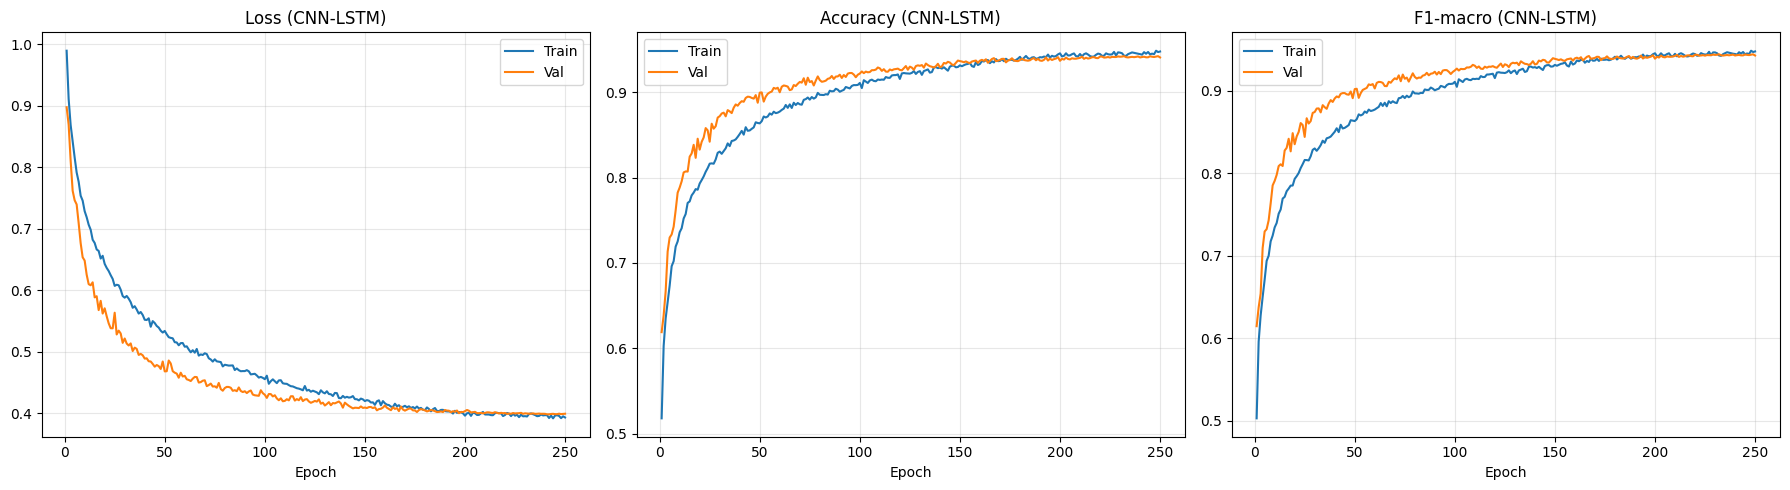

In [22]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["val_loss"], label="Val")
axes[0].set_title("Loss (CNN-LSTM)"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="Train")
axes[1].plot(epochs_range, history["val_acc"], label="Val")
axes[1].set_title("Accuracy (CNN-LSTM)"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_range, history["train_f1"], label="Train")
axes[2].plot(epochs_range, history["val_f1"], label="Val")
axes[2].set_title("F1-macro (CNN-LSTM)"); axes[2].set_xlabel("Epoch"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "training_curves_cnn_lstm.png", dpi=150)
plt.show()


### 7.6 Évaluation finale sur le test set

=== Rapport de classification CNN-LSTM (test) ===
              precision    recall  f1-score   support

        fall     0.9740    0.9627    0.9683      1635
      nfall1     0.9451    0.9342    0.9397      2250
      nfall2     0.9233    0.9427    0.9329      2145

    accuracy                         0.9449      6030
   macro avg     0.9475    0.9465    0.9469      6030
weighted avg     0.9452    0.9449    0.9450      6030



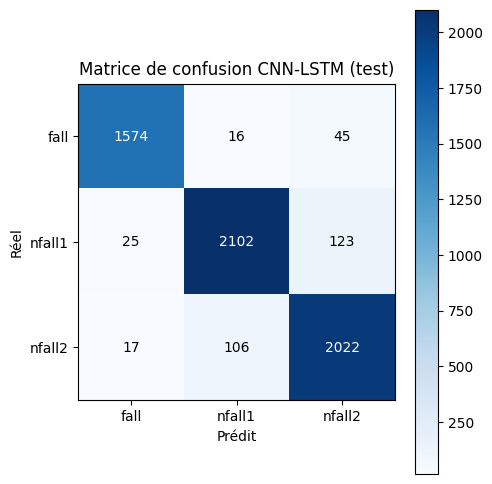


Meilleure val_acc: 0.9421


In [23]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        out = model(x)
        preds = out.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(y.numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

print("=== Rapport de classification CNN-LSTM (test) ===")
print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=4))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES)
ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")
ax.set_title("Matrice de confusion CNN-LSTM (test)")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im)
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrix_cnn_lstm.png", dpi=150)
plt.show()

print(f"\nMeilleure val_acc: {best_val_acc:.4f}")

RESULTS["CNN_LSTM"] = {
    "best_val_acc": best_val_acc,
    "test_accuracy": float((all_preds == all_labels).mean()),
    "test_f1_macro": float(f1_score(all_labels, all_preds, average="macro")),
}


### 7.7 Nettoyage mémoire

In [24]:
del model, optimizer, scheduler, train_loader, val_loader, test_loader
del train_ds, val_ds, test_ds, sampler, history, all_preds, all_labels, cm
gc.collect()
torch.cuda.empty_cache()
print("Mémoire du modèle CNN-LSTM libérée.")


Mémoire du modèle CNN-LSTM libérée.


## 8. Modèle 3 — Two-Stream Conv-Transformer (Conformer) — *THAR*

Architecture, prétraitement du `Dataset`/`DataLoader` et protocole d'entraînement **strictement identiques** au notebook d'origine `thar-csi.ipynb` : deux flux (amplitude / phase) passés dans un `ConvStream` CNN 2D chacun, puis un encodeur Transformer de type **Conformer** (attention + module convolutif) avec encodage positionnel et pooling temporel global.

### 8.1 Hyperparamètres du modèle

In [25]:
D_MODEL = 128
N_HEAD = 4
N_LAYERS = 4
DIM_FF = 256

CKPT_PATH = OUT_DIR / "best_model_thar.pt"
HISTORY_PATH = OUT_DIR / "history_thar.json"


### 8.2 Dataset & DataLoader (flux amplitude / phase séparés)

In [26]:
class CSIDataset(Dataset):
    def __init__(self, amp_arr, pha_arr, labels, indices, augment=False):
        self.amp = amp_arr
        self.pha = pha_arr
        self.labels = labels
        self.indices = indices
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        amp = self.amp[idx].astype(np.float32)
        pha = self.pha[idx].astype(np.float32)

        amp = (amp - AMP_MEAN) / AMP_STD
        pha = pha / np.pi   # phase assainie déjà bornée, on ramène ~[-1,1]

        if self.augment:
            amp = amp + np.random.normal(0, 0.02, amp.shape).astype(np.float32)
            if np.random.rand() < 0.3:
                t0 = np.random.randint(0, max(1, amp.shape[0] - 5))
                amp[t0:t0 + 5] = 0; pha[t0:t0 + 5] = 0
            if np.random.rand() < 0.3:
                f0 = np.random.randint(0, max(1, amp.shape[1] - 4))
                amp[:, f0:f0 + 4] = 0; pha[:, f0:f0 + 4] = 0

        label = self.labels[idx]
        return (
            torch.from_numpy(amp),
            torch.from_numpy(pha),
            torch.tensor(label, dtype=torch.long),
        )

train_ds = CSIDataset(AMP, PHA, LABELS, idx_train, augment=True)
val_ds = CSIDataset(AMP, PHA, LABELS, idx_val, augment=False)
test_ds = CSIDataset(AMP, PHA, LABELS, idx_test, augment=False)

sampler = WeightedRandomSampler(weights=sampler_weights, num_samples=len(idx_train), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                           num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)


### 8.3 Architecture : Two-Stream Conv-Transformer (Conformer)

In [27]:
class ConvStream(nn.Module):
    """Extracteur CNN 2D (temps x fréquence) par flux (amplitude ou phase)."""
    def __init__(self, in_channels=IN_CHANNELS, base=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, base, kernel_size=3, padding=1),
            nn.BatchNorm2d(base), nn.ReLU(),
            nn.Conv2d(base, base, kernel_size=3, padding=1),
            nn.BatchNorm2d(base), nn.ReLU(),
            nn.MaxPool2d(kernel_size=(1, 2)),      # F: 30 -> 15
            nn.Dropout2d(0.2),
            nn.Conv2d(base, base * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(base * 2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=(1, 2)),      # F: 15 -> 7
            nn.Dropout2d(0.2),
        )

    def forward(self, x):
        # x: (B,T,F,C) -> (B,C,T,F)
        x = x.permute(0, 3, 1, 2)
        out = self.net(x)                          # (B, base*2, T, F')
        out = out.permute(0, 2, 1, 3)               # (B,T,base*2,F')
        b, t, ch, fp = out.shape
        return out.reshape(b, t, ch * fp)            # (B,T,feat_dim)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=64):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class ConvModule(nn.Module):
    """Module convolutif type Conformer, inséré dans chaque bloc du Transformer."""
    def __init__(self, d_model, kernel_size=7, dropout=0.2):
        super().__init__()
        self.ln = nn.LayerNorm(d_model)
        self.pw1 = nn.Conv1d(d_model, 2 * d_model, 1)
        self.glu = nn.GLU(dim=1)
        self.dw = nn.Conv1d(d_model, d_model, kernel_size, padding=kernel_size // 2, groups=d_model)
        self.bn = nn.BatchNorm1d(d_model)
        self.act = nn.SiLU()
        self.pw2 = nn.Conv1d(d_model, d_model, 1)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):  # x: (B,T,D)
        y = self.ln(x).transpose(1, 2)
        y = self.glu(self.pw1(y))
        y = self.act(self.bn(self.dw(y)))
        y = self.drop(self.pw2(y)).transpose(1, 2)
        return x + y


class ConformerBlock(nn.Module):
    def __init__(self, d_model, nhead, dim_ff, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.drop1 = nn.Dropout(dropout)
        self.conv = ConvModule(d_model, dropout=dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, dim_ff), nn.SiLU(), nn.Dropout(dropout),
            nn.Linear(dim_ff, d_model), nn.Dropout(dropout),
        )

    def forward(self, x):
        y = self.ln1(x)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x = x + self.drop1(attn_out)
        x = self.conv(x)
        y = self.ln2(x)
        return x + self.ff(y)


class TwoStreamConvTransformer(nn.Module):
    def __init__(self, in_channels=IN_CHANNELS, d_model=D_MODEL, nhead=N_HEAD,
                 num_layers=N_LAYERS, dim_ff=DIM_FF, num_classes=len(CLASSES), dropout=DROPOUT):
        super().__init__()
        self.amp_stream = ConvStream(in_channels)
        self.pha_stream = ConvStream(in_channels)
        with torch.no_grad():
            dummy = torch.zeros(1, T_STEPS, F_SUB, in_channels)
            feat_dim = self.amp_stream(dummy).shape[-1]
        self.proj = nn.Linear(feat_dim * 2, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=T_STEPS + 4)
        self.blocks = nn.ModuleList(
            [ConformerBlock(d_model, nhead, dim_ff, dropout) for _ in range(num_layers)]
        )
        self.norm = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes),
        )

    def forward(self, amp, pha):
        a = self.amp_stream(amp)
        p = self.pha_stream(pha)
        x = torch.cat([a, p], dim=-1)
        x = self.pos_enc(self.proj(x))
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x).mean(dim=1)     # pooling temporel global
        x = self.drop(x)
        return self.classifier(x)


model = TwoStreamConvTransformer().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Nombre de paramètres: {n_params:,}")


Nombre de paramètres: 918,979


### 8.4 Entraînement

In [28]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    torch.set_grad_enabled(train)
    for amp, pha, y in loader:
        amp, pha, y = amp.to(DEVICE), pha.to(DEVICE), y.to(DEVICE)
        if train:
            optimizer.zero_grad()
        out = model(amp, pha)
        loss = criterion(out, y)
        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
        total_loss += loss.item() * y.size(0)
        preds = out.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
        all_preds.append(preds.detach().cpu().numpy())
        all_labels.append(y.detach().cpu().numpy())
    torch.set_grad_enabled(True)
    avg_loss = total_loss / total
    acc = correct / total
    f1 = f1_score(np.concatenate(all_labels), np.concatenate(all_preds), average="macro")
    return avg_loss, acc, f1


In [29]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [],
           "train_f1": [], "val_f1": []}
best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc, tr_f1 = run_epoch(train_loader, train=True)
    val_loss, val_acc, val_f1 = run_epoch(val_loader, train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)
    history["train_f1"].append(tr_f1); history["val_f1"].append(val_f1)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CKPT_PATH)
        flag = " (meilleur -> sauvegardé)"
    else:
        flag = ""

    dt = time.time() - t0
    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train_loss={tr_loss:.4f} acc={tr_acc:.4f} f1={tr_f1:.4f} | "
          f"val_loss={val_loss:.4f} acc={val_acc:.4f} f1={val_f1:.4f} | "
          f"{dt:.1f}s{flag}")

with open(HISTORY_PATH, "w") as f:
    json.dump(history, f)


Epoch 01/250 | train_loss=0.9312 acc=0.5763 f1=0.5659 | val_loss=0.8619 acc=0.6272 f1=0.6194 | 21.0s (meilleur -> sauvegardé)
Epoch 02/250 | train_loss=0.8205 acc=0.6720 f1=0.6681 | val_loss=0.7087 acc=0.7516 f1=0.7527 | 20.9s (meilleur -> sauvegardé)
Epoch 03/250 | train_loss=0.7662 acc=0.7149 f1=0.7133 | val_loss=0.6739 acc=0.7609 f1=0.7610 | 20.7s (meilleur -> sauvegardé)
Epoch 04/250 | train_loss=0.7218 acc=0.7423 f1=0.7418 | val_loss=0.6409 acc=0.7876 f1=0.7896 | 20.7s (meilleur -> sauvegardé)
Epoch 05/250 | train_loss=0.6909 acc=0.7653 f1=0.7649 | val_loss=0.6127 acc=0.8138 f1=0.8171 | 20.9s (meilleur -> sauvegardé)
Epoch 06/250 | train_loss=0.6674 acc=0.7794 f1=0.7784 | val_loss=0.6574 acc=0.7892 f1=0.7933 | 21.1s
Epoch 07/250 | train_loss=0.6538 acc=0.7875 f1=0.7870 | val_loss=0.5775 acc=0.8333 f1=0.8372 | 20.7s (meilleur -> sauvegardé)
Epoch 08/250 | train_loss=0.6450 acc=0.7940 f1=0.7937 | val_loss=0.5602 acc=0.8413 f1=0.8443 | 20.7s (meilleur -> sauvegardé)
Epoch 09/250 | tr

### 8.5 Courbes d'entraînement

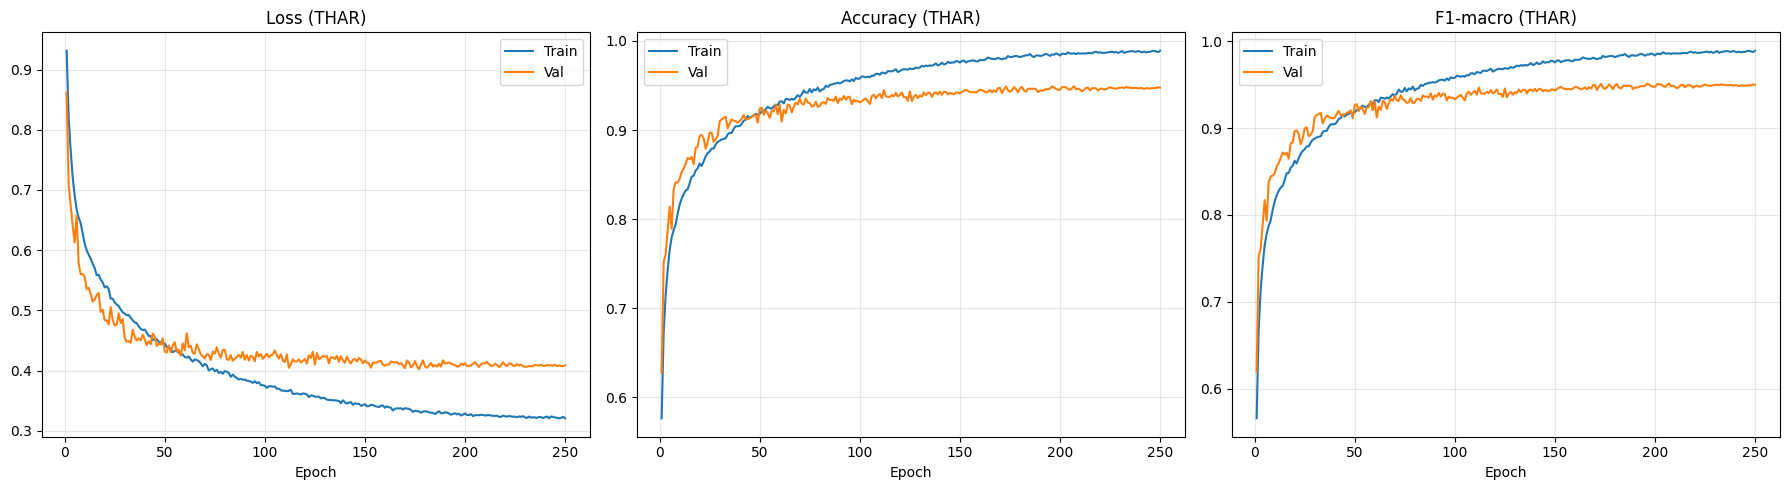

In [30]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["val_loss"], label="Val")
axes[0].set_title("Loss (THAR)"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="Train")
axes[1].plot(epochs_range, history["val_acc"], label="Val")
axes[1].set_title("Accuracy (THAR)"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_range, history["train_f1"], label="Train")
axes[2].plot(epochs_range, history["val_f1"], label="Val")
axes[2].set_title("F1-macro (THAR)"); axes[2].set_xlabel("Epoch"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "training_curves_thar.png", dpi=150)
plt.show()


### 8.6 Évaluation finale sur le test set

=== Rapport de classification THAR (test) ===
              precision    recall  f1-score   support

        fall     0.9789    0.9639    0.9713      1635
      nfall1     0.9486    0.9360    0.9423      2250
      nfall2     0.9295    0.9534    0.9413      2145

    accuracy                         0.9498      6030
   macro avg     0.9524    0.9511    0.9516      6030
weighted avg     0.9501    0.9498    0.9498      6030



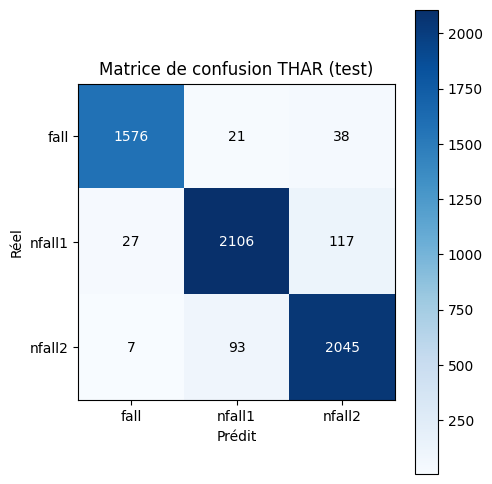


Meilleure val_acc pendant l'entrainement: 0.9493


In [31]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for amp, pha, y in test_loader:
        amp, pha = amp.to(DEVICE), pha.to(DEVICE)
        out = model(amp, pha)
        preds = out.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(y.numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

print("=== Rapport de classification THAR (test) ===")
print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=4))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES)
ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")
ax.set_title("Matrice de confusion THAR (test)")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im)
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrix_thar.png", dpi=150)
plt.show()

print(f"\nMeilleure val_acc pendant l'entrainement: {best_val_acc:.4f}")

RESULTS["THAR_ConvTransformer"] = {
    "best_val_acc": best_val_acc,
    "test_accuracy": float((all_preds == all_labels).mean()),
    "test_f1_macro": float(f1_score(all_labels, all_preds, average="macro")),
}


### 8.7 Sauvegarde du modèle final (pour fusion éventuelle)

Comme dans le notebook d'origine `thar-csi.ipynb`, ce modèle est en plus sauvegardé dans un format prêt pour une éventuelle fusion avec d'autres modèles.

In [32]:
FINAL_MODEL_PATH = OUT_DIR / "model_finetuned_best_thar.pth"

# Recharger le meilleur checkpoint sauvegardé pendant l'entraînement
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

torch.save({
    "model_state_dict": model.state_dict(),
    "best_val_acc": best_val_acc,
    "classes": CLASSES,
}, FINAL_MODEL_PATH)

print("✅ Modèle sauvegardé avec succès !")
print(f"📁 Chemin : {FINAL_MODEL_PATH}")
print(f"🏆 Meilleure validation accuracy : {best_val_acc:.4f}")


✅ Modèle sauvegardé avec succès !
📁 Chemin : /kaggle/working/model_finetuned_best_thar.pth
🏆 Meilleure validation accuracy : 0.9493


### 8.8 Nettoyage mémoire

In [33]:
del model, optimizer, scheduler, train_loader, val_loader, test_loader
del train_ds, val_ds, test_ds, sampler, history, all_preds, all_labels, cm
gc.collect()
torch.cuda.empty_cache()
print("Mémoire du modèle THAR libérée.")


Mémoire du modèle THAR libérée.


### 8.9 Récapitulatif comparatif des résultats

Comparaison finale de la baseline ML classique et des 3 modèles deep learning sur le **test set** (mêmes `idx_test` pour tous les modèles, donc comparaison directe).

                        accuracy  f1_macro  test_accuracy  test_f1_macro  \
ML_Logistic Regression  0.566335  0.562505            NaN            NaN   
ML_Random Forest        0.847098  0.848192            NaN            NaN   
ML_XGBoost              0.834163  0.834966            NaN            NaN   
ML_SVM (RBF)            0.687065  0.685798            NaN            NaN   
CNN_BiGRU                    NaN       NaN       0.942289       0.944119   
CNN_LSTM                     NaN       NaN       0.944942       0.946947   
THAR_ConvTransformer         NaN       NaN       0.949751       0.951645   

                        best_val_acc  
ML_Logistic Regression           NaN  
ML_Random Forest                 NaN  
ML_XGBoost                       NaN  
ML_SVM (RBF)                     NaN  
CNN_BiGRU                   0.946766  
CNN_LSTM                    0.942123  
THAR_ConvTransformer        0.949254  


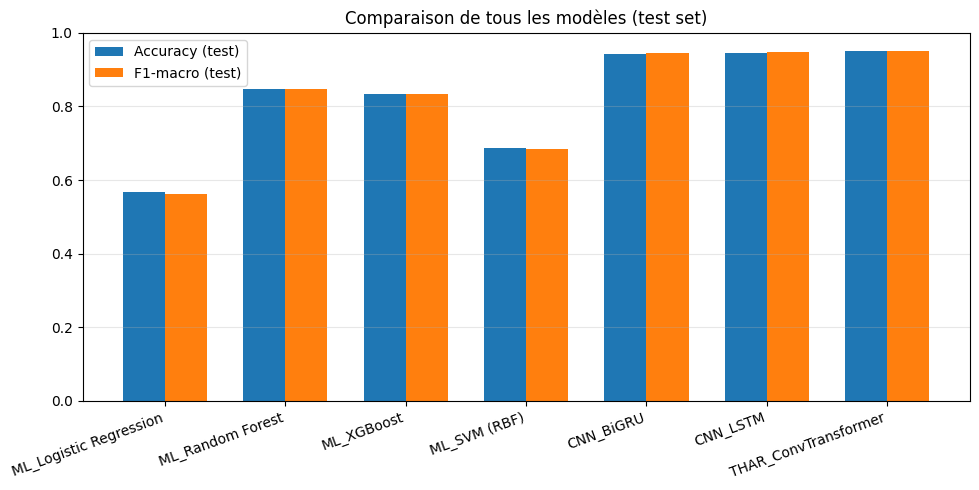


✅ Récapitulatif sauvegardé dans results_summary.json


In [34]:
results_df = pd.DataFrame(RESULTS).T
results_df = results_df[[c for c in ["accuracy", "f1_macro", "test_accuracy", "test_f1_macro", "best_val_acc"] if c in results_df.columns]]
print(results_df)

# Vue unifiée: accuracy test + f1-macro test pour tous les modèles (ML + DL)
acc_col = results_df["accuracy"].combine_first(results_df.get("test_accuracy", pd.Series(dtype=float)))
f1_col = results_df["f1_macro"].combine_first(results_df.get("test_f1_macro", pd.Series(dtype=float)))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df.index))
w = 0.35
ax.bar(x - w/2, acc_col.values, width=w, label="Accuracy (test)")
ax.bar(x + w/2, f1_col.values, width=w, label="F1-macro (test)")
ax.set_xticks(x); ax.set_xticklabels(results_df.index, rotation=20, ha="right")
ax.set_ylim(0, 1)
ax.set_title("Comparaison de tous les modèles (test set)")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(OUT_DIR / "all_models_comparison.png", dpi=150)
plt.show()

with open(OUT_DIR / "results_summary.json", "w") as f:
    json.dump(RESULTS, f, indent=2)
print("\n✅ Récapitulatif sauvegardé dans results_summary.json")


## 9. Modèle 4 — ResNet-18 (CSI-as-image)

### 9.1 Hyperparamètres du modèle

In [35]:
# Reutilise le flux unique amplitude+phase concatene (identique a la section 7 CNN-LSTM)
CKPT_PATH = OUT_DIR / "best_model_resnet18.pt"
HISTORY_PATH = OUT_DIR / "history_resnet18.json"

### 9.2 Dataset & DataLoader (flux unique amplitude+phase concaténé)

In [36]:
class CSIDataset(Dataset):
    def __init__(self, amp_arr, pha_arr, labels, indices, augment=False):
        self.amp = amp_arr
        self.pha = pha_arr
        self.labels = labels
        self.indices = indices
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        amp = self.amp[idx].astype(np.float32)
        pha = self.pha[idx].astype(np.float32)

        amp = (amp - AMP_MEAN) / AMP_STD
        pha = pha / np.pi

        if self.augment:
            amp = amp + np.random.normal(0, 0.02, amp.shape).astype(np.float32)
            if np.random.rand() < 0.3:
                t0 = np.random.randint(0, max(1, amp.shape[0] - 5))
                amp[t0:t0 + 5] = 0; pha[t0:t0 + 5] = 0
            if np.random.rand() < 0.3:
                f0 = np.random.randint(0, max(1, amp.shape[1] - 4))
                amp[:, f0:f0 + 4] = 0; pha[:, f0:f0 + 4] = 0

        x = np.concatenate([amp, pha], axis=-1)   # (T,F,18) - flux unique
        label = self.labels[idx]
        return torch.from_numpy(x), torch.tensor(label, dtype=torch.long)

train_ds = CSIDataset(AMP, PHA, LABELS, idx_train, augment=True)
val_ds = CSIDataset(AMP, PHA, LABELS, idx_val, augment=False)
test_ds = CSIDataset(AMP, PHA, LABELS, idx_test, augment=False)

sampler = WeightedRandomSampler(weights=sampler_weights, num_samples=len(idx_train), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                           num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

### 9.3 Architecture : ResNet-18 (CSI traité comme une image temps×fréquence)

In [37]:
class BasicBlock(nn.Module):
    """Bloc résiduel standard ResNet (2 conv 3x3 + skip connection)."""
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = None
        if stride != 1 or in_planes != planes:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_planes, planes, 1, stride=stride, bias=False),
                nn.BatchNorm2d(planes),
            )

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        return self.relu(out)


class ResNet18_CSI(nn.Module):
    """ResNet-18 (stem + 4 stages de 2 BasicBlocks = 18 couches à poids),
    adapté aux petites 'images' CSI (T=50, F=30) : stem allégé sans maxpool
    agressif, contrairement au ResNet-18 ImageNet classique."""
    def __init__(self, in_channels=IN_CHANNELS_LSTM, num_classes=len(CLASSES), dropout=DROPOUT):
        super().__init__()
        self.in_planes = 64
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, planes, blocks, stride):
        layers = [BasicBlock(self.in_planes, planes, stride)]
        self.in_planes = planes
        for _ in range(1, blocks):
            layers.append(BasicBlock(self.in_planes, planes, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        # x: (B,T,F,C) -> (B,C,T,F) traité comme une image
        x = x.permute(0, 3, 1, 2)
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x); x = self.layer3(x); x = self.layer4(x)
        x = self.avgpool(x).flatten(1)
        x = self.drop(x)
        return self.fc(x)


model = ResNet18_CSI().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Nombre de paramètres: {n_params:,}")

Nombre de paramètres: 11,179,011


### 9.4 Entraînement

In [38]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    torch.set_grad_enabled(train)
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        if train:
            optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
        total_loss += loss.item() * y.size(0)
        preds = out.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
        all_preds.append(preds.detach().cpu().numpy())
        all_labels.append(y.detach().cpu().numpy())
    torch.set_grad_enabled(True)
    avg_loss = total_loss / total
    acc = correct / total
    f1 = f1_score(np.concatenate(all_labels), np.concatenate(all_preds), average="macro")
    return avg_loss, acc, f1

In [39]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [],
           "train_f1": [], "val_f1": []}
best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc, tr_f1 = run_epoch(train_loader, train=True)
    val_loss, val_acc, val_f1 = run_epoch(val_loader, train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)
    history["train_f1"].append(tr_f1); history["val_f1"].append(val_f1)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CKPT_PATH)
        flag = " (meilleur -> sauvegardé)"
    else:
        flag = ""

    dt = time.time() - t0
    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train_loss={tr_loss:.4f} acc={tr_acc:.4f} f1={tr_f1:.4f} | "
          f"val_loss={val_loss:.4f} acc={val_acc:.4f} f1={val_f1:.4f} | {dt:.1f}s{flag}")

with open(HISTORY_PATH, "w") as f:
    json.dump(history, f)

Epoch 01/250 | train_loss=0.8235 acc=0.6762 f1=0.6746 | val_loss=0.7631 acc=0.7318 f1=0.7324 | 63.8s (meilleur -> sauvegardé)
Epoch 02/250 | train_loss=0.6550 acc=0.7915 f1=0.7914 | val_loss=0.6490 acc=0.7884 f1=0.7878 | 63.9s (meilleur -> sauvegardé)
Epoch 03/250 | train_loss=0.5847 acc=0.8346 f1=0.8344 | val_loss=0.6120 acc=0.8196 f1=0.8199 | 63.6s (meilleur -> sauvegardé)
Epoch 04/250 | train_loss=0.5483 acc=0.8561 f1=0.8558 | val_loss=0.5320 acc=0.8602 f1=0.8628 | 63.5s (meilleur -> sauvegardé)
Epoch 05/250 | train_loss=0.5136 acc=0.8759 f1=0.8755 | val_loss=0.5433 acc=0.8597 f1=0.8623 | 63.6s
Epoch 06/250 | train_loss=0.4968 acc=0.8855 f1=0.8857 | val_loss=0.5081 acc=0.8821 f1=0.8848 | 63.9s (meilleur -> sauvegardé)
Epoch 07/250 | train_loss=0.4685 acc=0.9014 f1=0.9015 | val_loss=0.4922 acc=0.8864 f1=0.8894 | 63.7s (meilleur -> sauvegardé)
Epoch 08/250 | train_loss=0.4612 acc=0.9066 f1=0.9065 | val_loss=0.4947 acc=0.8847 f1=0.8873 | 63.6s
Epoch 09/250 | train_loss=0.4532 acc=0.912

### 9.5 Courbes d'entraînement

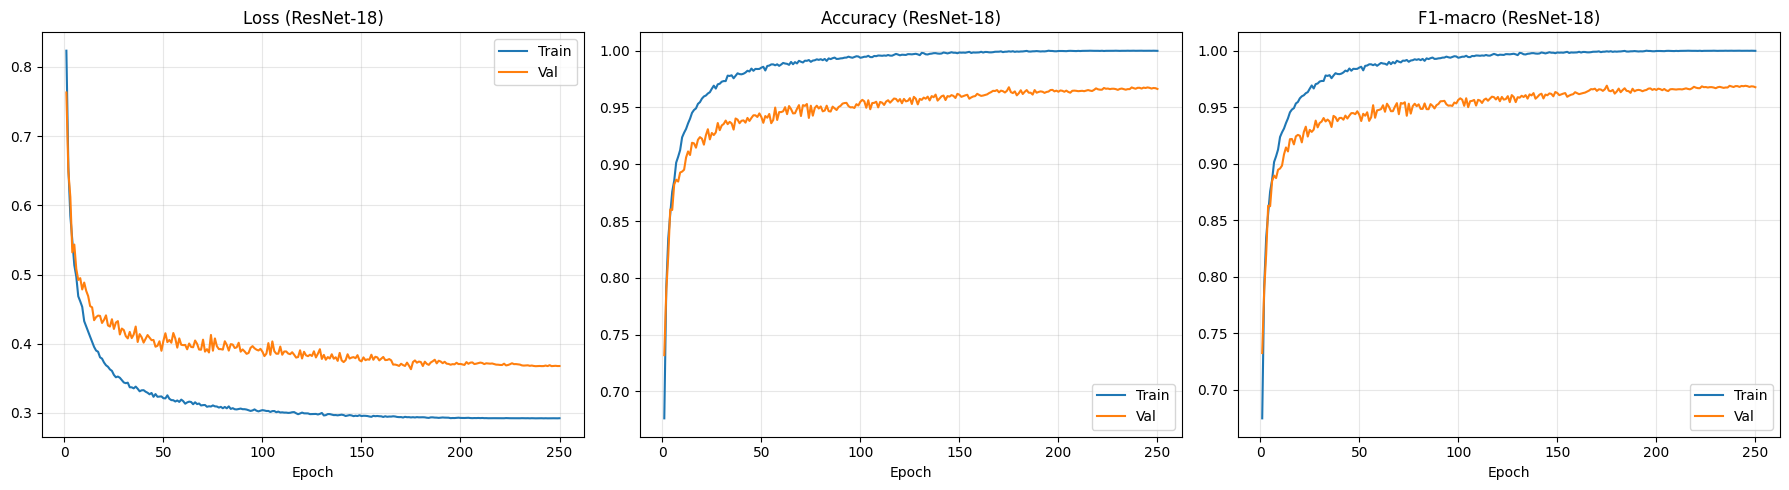

In [40]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["val_loss"], label="Val")
axes[0].set_title("Loss (ResNet-18)"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="Train")
axes[1].plot(epochs_range, history["val_acc"], label="Val")
axes[1].set_title("Accuracy (ResNet-18)"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_range, history["train_f1"], label="Train")
axes[2].plot(epochs_range, history["val_f1"], label="Val")
axes[2].set_title("F1-macro (ResNet-18)"); axes[2].set_xlabel("Epoch"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "training_curves_resnet18.png", dpi=150)
plt.show()

### 9.6 Évaluation finale sur le test set

=== Rapport de classification ResNet-18 (test) ===
              precision    recall  f1-score   support

        fall     0.9846    0.9780    0.9813      1635
      nfall1     0.9574    0.9689    0.9631      2250
      nfall2     0.9648    0.9576    0.9612      2145

    accuracy                         0.9673      6030
   macro avg     0.9689    0.9681    0.9685      6030
weighted avg     0.9674    0.9673    0.9673      6030



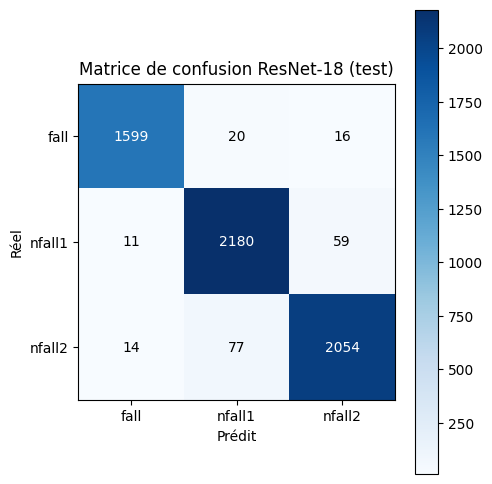


Meilleure val_acc pendant l'entrainement: 0.9678


In [41]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        out = model(x)
        preds = out.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(y.numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

print("=== Rapport de classification ResNet-18 (test) ===")
print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=4))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES)
ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")
ax.set_title("Matrice de confusion ResNet-18 (test)")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im)
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrix_resnet18.png", dpi=150)
plt.show()

print(f"\nMeilleure val_acc pendant l'entrainement: {best_val_acc:.4f}")

RESULTS["ResNet18"] = {
    "best_val_acc": best_val_acc,
    "test_accuracy": float((all_preds == all_labels).mean()),
    "test_f1_macro": float(f1_score(all_labels, all_preds, average="macro")),
}

### 9.7 Nettoyage mémoire

In [42]:
del model, optimizer, scheduler, train_loader, val_loader, test_loader
del train_ds, val_ds, test_ds, sampler, history, all_preds, all_labels, cm
gc.collect()
torch.cuda.empty_cache()
print("Mémoire du modèle ResNet-18 libérée.")

Mémoire du modèle ResNet-18 libérée.


## 10. Modèle 5 — CSI-BERT2 (encodeur type BERT)

### 10.1 Hyperparamètres du modèle

In [43]:
BERT_D_MODEL = 128
BERT_NHEAD = 4
BERT_LAYERS = 4
BERT_DIM_FF = 256

CKPT_PATH = OUT_DIR / "best_model_csibert2.pt"
HISTORY_PATH = OUT_DIR / "history_csibert2.json"

### 10.2 Dataset & DataLoader (flux unique amplitude+phase concaténé)

In [44]:
class CSIDataset(Dataset):
    def __init__(self, amp_arr, pha_arr, labels, indices, augment=False):
        self.amp = amp_arr
        self.pha = pha_arr
        self.labels = labels
        self.indices = indices
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        amp = self.amp[idx].astype(np.float32)
        pha = self.pha[idx].astype(np.float32)

        amp = (amp - AMP_MEAN) / AMP_STD
        pha = pha / np.pi

        if self.augment:
            amp = amp + np.random.normal(0, 0.02, amp.shape).astype(np.float32)
            if np.random.rand() < 0.3:
                t0 = np.random.randint(0, max(1, amp.shape[0] - 5))
                amp[t0:t0 + 5] = 0; pha[t0:t0 + 5] = 0
            if np.random.rand() < 0.3:
                f0 = np.random.randint(0, max(1, amp.shape[1] - 4))
                amp[:, f0:f0 + 4] = 0; pha[:, f0:f0 + 4] = 0

        x = np.concatenate([amp, pha], axis=-1)   # (T,F,18) - flux unique
        label = self.labels[idx]
        return torch.from_numpy(x), torch.tensor(label, dtype=torch.long)

train_ds = CSIDataset(AMP, PHA, LABELS, idx_train, augment=True)
val_ds = CSIDataset(AMP, PHA, LABELS, idx_val, augment=False)
test_ds = CSIDataset(AMP, PHA, LABELS, idx_test, augment=False)

sampler = WeightedRandomSampler(weights=sampler_weights, num_samples=len(idx_train), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                           num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

### 10.3 Architecture : CSI-BERT2 (tokenisation par pas de temps + encodeur BERT)

In [45]:
class PatchEmbedCSI(nn.Module):
    """Convertit chaque pas de temps CSI (F,C) en un token via une tokenisation
    'patch' légère (petit CNN 2D), dans l'esprit efficace de CSI-BERT2,
    puis projette vers d_model."""
    def __init__(self, in_channels=IN_CHANNELS_LSTM, d_model=BERT_D_MODEL, base=32):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, base, kernel_size=3, padding=1),
            nn.BatchNorm2d(base), nn.GELU(),
            nn.MaxPool2d(kernel_size=(1, 2)),   # F: 30 -> 15
            nn.Conv2d(base, base, kernel_size=3, padding=1),
            nn.BatchNorm2d(base), nn.GELU(),
            nn.MaxPool2d(kernel_size=(1, 2)),   # F: 15 -> 7
        )
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, T_STEPS, F_SUB)
            out = self.conv(dummy)
            feat_dim = out.shape[1] * out.shape[3]
        self.proj = nn.Linear(feat_dim, d_model)

    def forward(self, x):
        # x: (B,T,F,C) -> (B,C,T,F)
        x = x.permute(0, 3, 1, 2)
        out = self.conv(x)                  # (B, base, T, F')
        out = out.permute(0, 2, 1, 3)         # (B,T,base,F')
        b, t, ch, fp = out.shape
        out = out.reshape(b, t, ch * fp)
        return self.proj(out)                 # (B,T,d_model)


class CSIBERT2(nn.Module):
    """Encodeur type BERT pour la classification CSI (inspiré de CSI-BERT2) :
    tokenisation par pas de temps, token [CLS] appris, encodage positionnel,
    empilement de blocs Transformer encoder (post-LN, GELU), classification
    sur la sortie du token [CLS]."""
    def __init__(self, in_channels=IN_CHANNELS_LSTM, d_model=BERT_D_MODEL, nhead=BERT_NHEAD,
                 num_layers=BERT_LAYERS, dim_ff=BERT_DIM_FF, num_classes=len(CLASSES), dropout=DROPOUT):
        super().__init__()
        self.patch_embed = PatchEmbedCSI(in_channels, d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, T_STEPS + 1, d_model))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=False,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.drop = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes),
        )

    def forward(self, x):
        tokens = self.patch_embed(x)                    # (B,T,d_model)
        b = tokens.shape[0]
        cls = self.cls_token.expand(b, -1, -1)           # (B,1,d_model)
        tokens = torch.cat([cls, tokens], dim=1)          # (B,T+1,d_model)
        tokens = tokens + self.pos_embed[:, :tokens.shape[1]]
        out = self.encoder(tokens)                        # (B,T+1,d_model)
        cls_out = self.drop(out[:, 0])                      # token [CLS]
        return self.classifier(cls_out)


model = CSIBERT2().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Nombre de paramètres: {n_params:,}")

Nombre de paramètres: 588,419


### 10.4 Entraînement

In [46]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    torch.set_grad_enabled(train)
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        if train:
            optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
        total_loss += loss.item() * y.size(0)
        preds = out.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
        all_preds.append(preds.detach().cpu().numpy())
        all_labels.append(y.detach().cpu().numpy())
    torch.set_grad_enabled(True)
    avg_loss = total_loss / total
    acc = correct / total
    f1 = f1_score(np.concatenate(all_labels), np.concatenate(all_preds), average="macro")
    return avg_loss, acc, f1

In [47]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [],
           "train_f1": [], "val_f1": []}
best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc, tr_f1 = run_epoch(train_loader, train=True)
    val_loss, val_acc, val_f1 = run_epoch(val_loader, train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)
    history["train_f1"].append(tr_f1); history["val_f1"].append(val_f1)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CKPT_PATH)
        flag = " (meilleur -> sauvegardé)"
    else:
        flag = ""

    dt = time.time() - t0
    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train_loss={tr_loss:.4f} acc={tr_acc:.4f} f1={tr_f1:.4f} | "
          f"val_loss={val_loss:.4f} acc={val_acc:.4f} f1={val_f1:.4f} | {dt:.1f}s{flag}")

with open(HISTORY_PATH, "w") as f:
    json.dump(history, f)

Epoch 01/250 | train_loss=0.9163 acc=0.5908 f1=0.5839 | val_loss=0.8190 acc=0.6655 f1=0.6614 | 14.4s (meilleur -> sauvegardé)
Epoch 02/250 | train_loss=0.7946 acc=0.6944 f1=0.6925 | val_loss=0.7537 acc=0.7229 f1=0.7209 | 15.3s (meilleur -> sauvegardé)
Epoch 03/250 | train_loss=0.7304 acc=0.7402 f1=0.7389 | val_loss=0.6975 acc=0.7655 f1=0.7660 | 15.1s (meilleur -> sauvegardé)
Epoch 04/250 | train_loss=0.6934 acc=0.7675 f1=0.7666 | val_loss=0.7142 acc=0.7476 f1=0.7496 | 15.1s
Epoch 05/250 | train_loss=0.6556 acc=0.7912 f1=0.7911 | val_loss=0.6562 acc=0.7834 f1=0.7849 | 15.0s (meilleur -> sauvegardé)
Epoch 06/250 | train_loss=0.6294 acc=0.8097 f1=0.8093 | val_loss=0.6023 acc=0.8149 f1=0.8182 | 15.2s (meilleur -> sauvegardé)
Epoch 07/250 | train_loss=0.6069 acc=0.8204 f1=0.8202 | val_loss=0.5990 acc=0.8211 f1=0.8235 | 15.0s (meilleur -> sauvegardé)
Epoch 08/250 | train_loss=0.5848 acc=0.8357 f1=0.8352 | val_loss=0.5808 acc=0.8328 f1=0.8357 | 15.1s (meilleur -> sauvegardé)
Epoch 09/250 | tr

### 10.5 Courbes d'entraînement

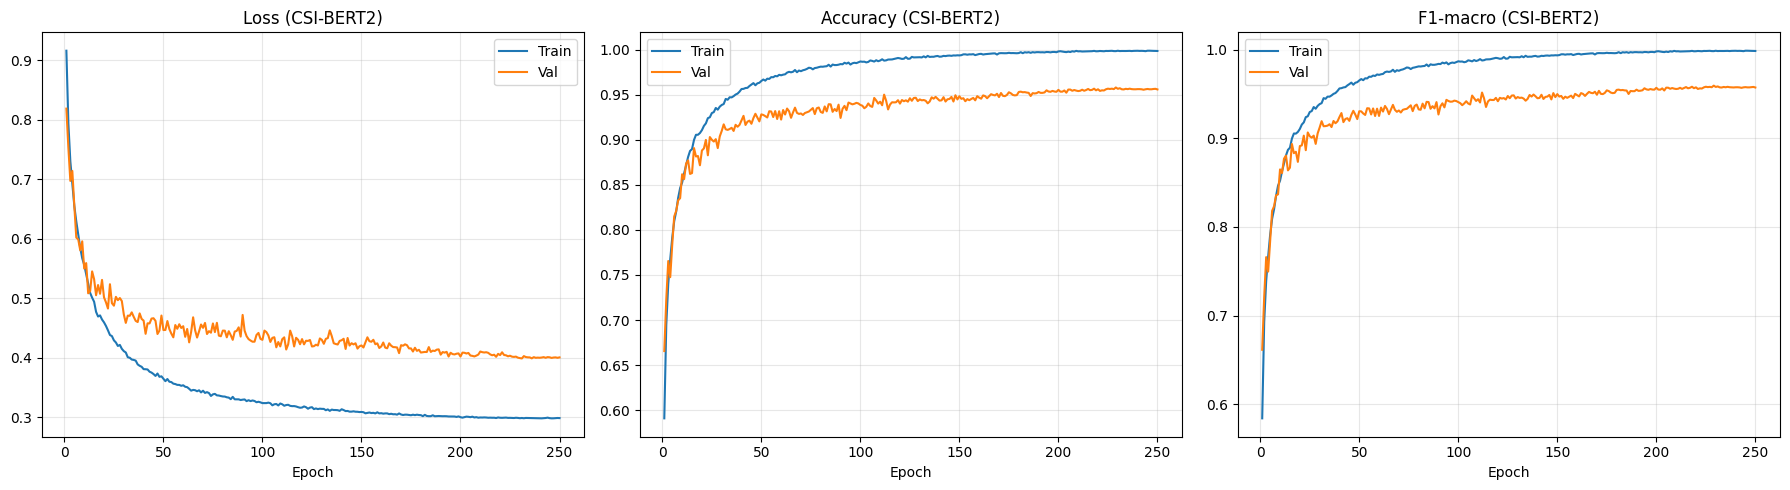

In [48]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["val_loss"], label="Val")
axes[0].set_title("Loss (CSI-BERT2)"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="Train")
axes[1].plot(epochs_range, history["val_acc"], label="Val")
axes[1].set_title("Accuracy (CSI-BERT2)"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_range, history["train_f1"], label="Train")
axes[2].plot(epochs_range, history["val_f1"], label="Val")
axes[2].set_title("F1-macro (CSI-BERT2)"); axes[2].set_xlabel("Epoch"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "training_curves_csibert2.png", dpi=150)
plt.show()

### 10.6 Évaluation finale sur le test set

=== Rapport de classification CSI-BERT2 (test) ===
              precision    recall  f1-score   support

        fall     0.9738    0.9761    0.9750      1635
      nfall1     0.9529    0.9440    0.9484      2250
      nfall2     0.9399    0.9473    0.9436      2145

    accuracy                         0.9539      6030
   macro avg     0.9555    0.9558    0.9557      6030
weighted avg     0.9539    0.9539    0.9539      6030



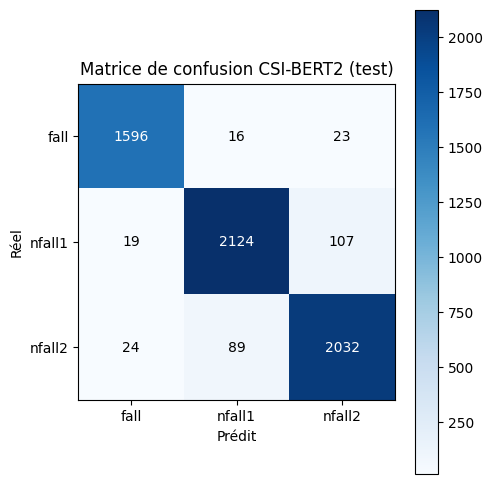


Meilleure val_acc pendant l'entrainement: 0.9582


In [49]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        out = model(x)
        preds = out.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(y.numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

print("=== Rapport de classification CSI-BERT2 (test) ===")
print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=4))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES)
ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")
ax.set_title("Matrice de confusion CSI-BERT2 (test)")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im)
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrix_csibert2.png", dpi=150)
plt.show()

print(f"\nMeilleure val_acc pendant l'entrainement: {best_val_acc:.4f}")

RESULTS["CSI_BERT2"] = {
    "best_val_acc": best_val_acc,
    "test_accuracy": float((all_preds == all_labels).mean()),
    "test_f1_macro": float(f1_score(all_labels, all_preds, average="macro")),
}

### 10.7 Nettoyage mémoire

In [50]:
del model, optimizer, scheduler, train_loader, val_loader, test_loader
del train_ds, val_ds, test_ds, sampler, history, all_preds, all_labels, cm
gc.collect()
torch.cuda.empty_cache()
print("Mémoire du modèle CSI-BERT2 libérée.")

Mémoire du modèle CSI-BERT2 libérée.


## 12. Récapitulatif comparatif — Modèles Deep Learning uniquement

                      test_accuracy  test_f1_macro  best_val_acc
CNN_BiGRU                  0.942289       0.944119      0.946766
CNN_LSTM                   0.944942       0.946947      0.942123
THAR_ConvTransformer       0.949751       0.951645      0.949254
ResNet18                   0.967330       0.968518      0.967828
CSI_BERT2                  0.953897       0.955653      0.958209


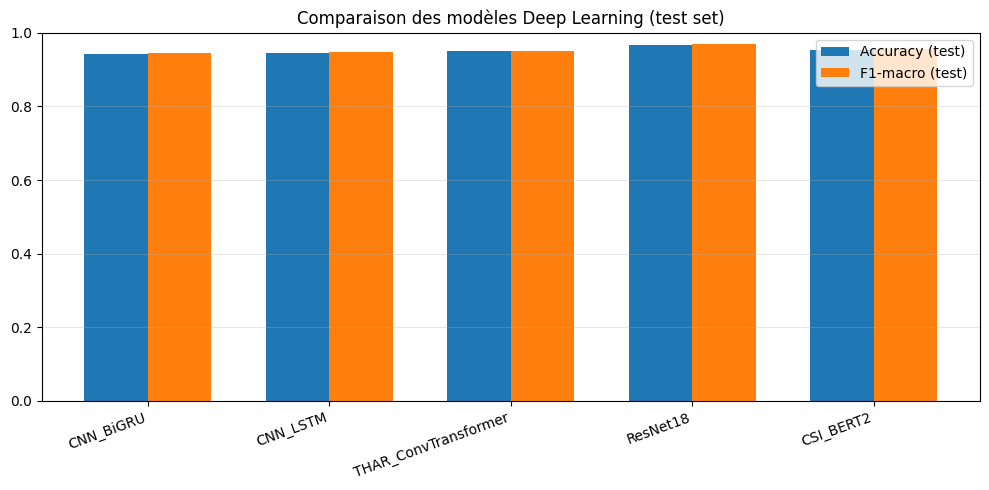


✅ Récapitulatif DL sauvegardé dans results_summary_dl.json
🏆 Meilleur modèle DL (F1-macro test): ResNet18 (0.9685)


In [51]:
# On exclut les baselines ML classique (clés préfixées "ML_") pour ne garder
# que les modèles DL : CNN_BiGRU, CNN_LSTM, THAR_ConvTransformer, ResNet18, CSI_BERT2
dl_results = {k: v for k, v in RESULTS.items() if not k.startswith("ML_")}

results_df_dl = pd.DataFrame(dl_results).T
results_df_dl = results_df_dl[[c for c in ["accuracy", "f1_macro", "test_accuracy", "test_f1_macro", "best_val_acc"] if c in results_df_dl.columns]]
print(results_df_dl)

acc_col = results_df_dl["accuracy"].combine_first(results_df_dl.get("test_accuracy", pd.Series(dtype=float))) if "accuracy" in results_df_dl.columns else results_df_dl["test_accuracy"]
f1_col = results_df_dl["f1_macro"].combine_first(results_df_dl.get("test_f1_macro", pd.Series(dtype=float))) if "f1_macro" in results_df_dl.columns else results_df_dl["test_f1_macro"]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df_dl.index))
w = 0.35
ax.bar(x - w/2, acc_col.values, width=w, label="Accuracy (test)")
ax.bar(x + w/2, f1_col.values, width=w, label="F1-macro (test)")
ax.set_xticks(x); ax.set_xticklabels(results_df_dl.index, rotation=20, ha="right")
ax.set_ylim(0, 1)
ax.set_title("Comparaison des modèles Deep Learning (test set)")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(OUT_DIR / "dl_models_comparison.png", dpi=150)
plt.show()

with open(OUT_DIR / "results_summary_dl.json", "w") as f:
    json.dump(dl_results, f, indent=2)
print("\n✅ Récapitulatif DL sauvegardé dans results_summary_dl.json")

best_dl_model = f1_col.idxmax()
print(f"🏆 Meilleur modèle DL (F1-macro test): {best_dl_model} ({f1_col.max():.4f})")